In [11]:
pip install opencv-contrib-python scikit-image pywavelets matplotlib pandas scikit-learn

In [12]:
!pip install keras-facenet

In [13]:
import cv2
import os
import numpy as np
import pywt
import pandas as pd
import matplotlib.pyplot as plt
from keras_facenet import FaceNet
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
!ls "/content/drive/MyDrive/DIP Dataset 4 AT and T Dataset"

README	s11  s14  s17  s2   s22  s25  s28  s30	s33  s36  s39  s5  s8
s1	s12  s15  s18  s20  s23  s26  s29  s31	s34  s37  s4   s6  s9
s10	s13  s16  s19  s21  s24  s27  s3   s32	s35  s38  s40  s7


In [16]:
import cv2
import os
import numpy as np

dataset_path = "/content/drive/MyDrive/DIP Dataset 4 AT and T Dataset"

images = []
labels = []

for person in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person)

    if not os.path.isdir(person_path):
        continue

    # label comes from folder name s1, s2, s3...
    label = int(person.replace("s",""))

    for img_name in os.listdir(person_path):

        img_path = os.path.join(person_path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        gray = cv2.resize(gray, (100,100))

        images.append(gray)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("Total images loaded:", len(images))
print("Total labels:", len(labels))

Total images loaded: 400
Total labels: 400


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.5,
    stratify=labels,
    random_state=42
)

In [18]:
def compute_metrics(preds):

    acc = accuracy_score(y_test,preds)*100
    prec = precision_score(y_test,preds,average='macro')*100
    rec = recall_score(y_test,preds,average='macro')*100
    f1 = f1_score(y_test,preds,average='macro')*100

    return acc,prec,rec,f1

In [19]:
def image_quality(original, processed):

    original = original.astype(np.uint8)
    processed = processed.astype(np.uint8)

    p = psnr(original, processed, data_range=255)

    s, _ = ssim(original, processed, full=True, data_range=255)

    return p, s

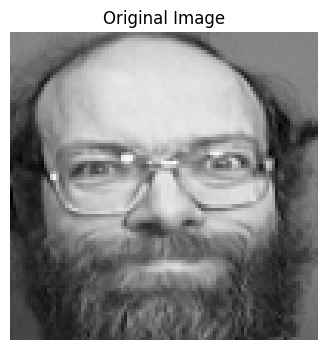

In [20]:
import matplotlib.pyplot as plt

sample = images[0]

plt.figure(figsize=(4,4))
plt.imshow(sample, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [21]:
def median_filter(img):
    return cv2.medianBlur(img,3)

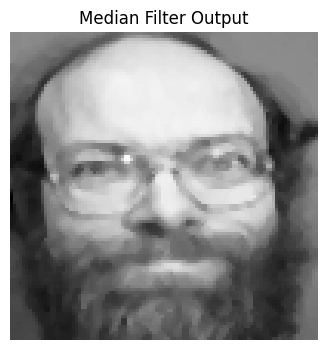

In [22]:
median_img = median_filter(sample)

plt.figure(figsize=(4,4))
plt.imshow(median_img, cmap='gray')
plt.title("Median Filter Output")
plt.axis("off")
plt.show()

In [23]:
def gray_normalization(img):

    norm = cv2.normalize(img,None,0,255,cv2.NORM_MINMAX)

    return norm

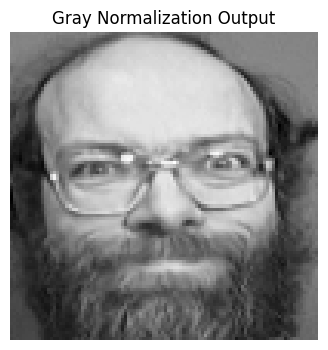

In [24]:
graynorm_img = gray_normalization(sample)

plt.figure(figsize=(4,4))
plt.imshow(graynorm_img, cmap='gray')
plt.title("Gray Normalization Output")
plt.axis("off")
plt.show()

In [25]:
def geometric_norm(img):

    rows,cols = img.shape

    M = cv2.getRotationMatrix2D((cols/2,rows/2),5,1)

    return cv2.warpAffine(img,M,(cols,rows))

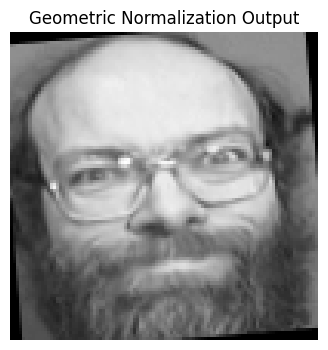

In [26]:
geom_img = geometric_norm(sample)

plt.figure(figsize=(4,4))
plt.imshow(geom_img, cmap='gray')
plt.title("Geometric Normalization Output")
plt.axis("off")
plt.show()

In [27]:
def wavelet_transform(img):

    coeffs = pywt.dwt2(img,'haar')

    LL,(LH,HL,HH) = coeffs

    return cv2.resize(LL,(100,100))

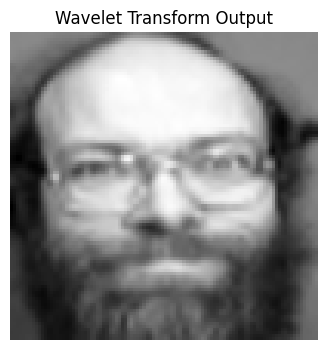

In [28]:
wavelet_img = wavelet_transform(sample)

plt.figure(figsize=(4,4))
plt.imshow(wavelet_img, cmap='gray')
plt.title("Wavelet Transform Output")
plt.axis("off")
plt.show()

In [29]:
def hist_eq(img):

    return cv2.equalizeHist(img)

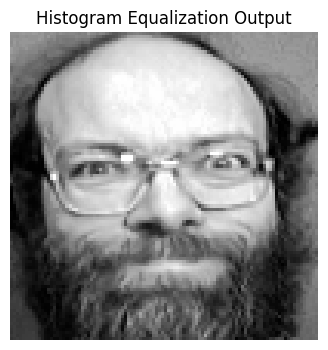

In [30]:
hist_img = hist_eq(sample)

plt.figure(figsize=(4,4))
plt.imshow(hist_img, cmap='gray')
plt.title("Histogram Equalization Output")
plt.axis("off")
plt.show()

In [31]:
methods = {
"Original":lambda x:x,
"Median":median_filter,
"GrayNorm":gray_normalization,
"Geometric":geometric_norm,
"Wavelet":wavelet_transform,
"Histogram":hist_eq,
}

results=[]
accuracies=[]

In [32]:
from keras_facenet import FaceNet
from sklearn.svm import SVC

embedder = FaceNet()

In [33]:
def prepare_for_facenet(images):

    processed = []

    for img in images:

        img = img.astype(np.uint8)

        img = cv2.resize(img,(160,160))

        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        processed.append(img)

    return np.array(processed)

In [34]:
results=[]

for name, func in methods.items():

    # Apply preprocessing
    X_train_proc = np.array([func(img) for img in X_train])
    X_test_proc = np.array([func(img) for img in X_test])

    # Convert for FaceNet
    X_train_face = prepare_for_facenet(X_train_proc)
    X_test_face = prepare_for_facenet(X_test_proc)

    # Face embeddings
    train_embeddings = embedder.embeddings(X_train_face)
    test_embeddings = embedder.embeddings(X_test_face)

    # Train classifier
    model = SVC(kernel='linear', C=0.5)
    model.fit(train_embeddings, y_train)

    preds = model.predict(test_embeddings)

    # Classification metrics
    acc = accuracy_score(y_test, preds) * 100
    prec = precision_score(y_test, preds, average='macro') * 100
    rec = recall_score(y_test, preds, average='macro') * 100
    f1 = f1_score(y_test, preds, average='macro') * 100

    # Image quality metrics
    psnr_vals = []
    ssim_vals = []

    for i in range(len(X_test)):
        p, s = image_quality(X_test[i], X_test_proc[i])
        psnr_vals.append(p)
        ssim_vals.append(s)

    psnr_avg = np.mean(psnr_vals)
    ssim_avg = np.mean(ssim_vals)

    results.append([name, acc, prec, rec, f1, psnr_avg, ssim_avg])

    print(name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("PSNR:", psnr_avg)
    print("SSIM:", ssim_avg)
    print("---------------------")

7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step


/usr/local/lib/python3.12/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


Original
Accuracy: 100.0
Precision: 100.0
Recall: 100.0
F1 Score: 100.0
PSNR: inf
SSIM: 1.0
---------------------
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
Median
Accuracy: 100.0
Precision: 100.0
Recall: 100.0
F1 Score: 100.0
PSNR: 35.01687306623634
SSIM: 0.9609218204535046
---------------------
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step
GrayNorm
Accuracy: 100.0
Precision: 100.0
Recall: 100.0
F1 Score: 100.0
PSNR: 22.777049230733102
SSIM: 0.9636029988211037
---------------------
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
Geometric
Accuracy: 100.0
Precision: 100.0
Recall: 100.0
F1 Score: 100.0
PSNR: 19.811006254327822
SSIM: 0.6412478321516827
---------------------
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Wavelet
Accuracy: 71.5
Precision: 77.8163086913087
Recall: 71.5
F1 Score: 70.21022143061616
PSNR: 8.91827059471163
SSIM: 0.3289917653074189
---------------------
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
Histogram
Accuracy: 100.0
Precision: 100.0
Recall: 100.0
F1 Score: 100.0
PSNR: 17.520827428695483
SSIM: 0.8262461918146239
---------------------


In [35]:
columns = ["Method","Accuracy","Precision","Recall","F1 Score","PSNR","SSIM"]

df = pd.DataFrame(results, columns=columns)

print(df)

      Method  Accuracy   Precision  Recall    F1 Score       PSNR      SSIM
0   Original     100.0  100.000000   100.0  100.000000        inf  1.000000
1     Median     100.0  100.000000   100.0  100.000000  35.016873  0.960922
2   GrayNorm     100.0  100.000000   100.0  100.000000  22.777049  0.963603
3  Geometric     100.0  100.000000   100.0  100.000000  19.811006  0.641248
4    Wavelet      71.5   77.816309    71.5   70.210221   8.918271  0.328992
5  Histogram     100.0  100.000000   100.0  100.000000  17.520827  0.826246


In [36]:
display(df)

,Method,Accuracy,Precision,Recall,F1 Score,PSNR,SSIM
0,Original,100.0,100.000000,100.0,100.000000,inf,1.000000
1,Median,100.0,100.000000,100.0,100.000000,35.016873,0.960922
2,GrayNorm,100.0,100.000000,100.0,100.000000,22.777049,0.963603
3,Geometric,100.0,100.000000,100.0,100.000000,19.811006,0.641248
4,Wavelet,71.5,77.816309,71.5,70.210221,8.918271,0.328992
5,Histogram,100.0,100.000000,100.0,100.000000,17.520827,0.826246


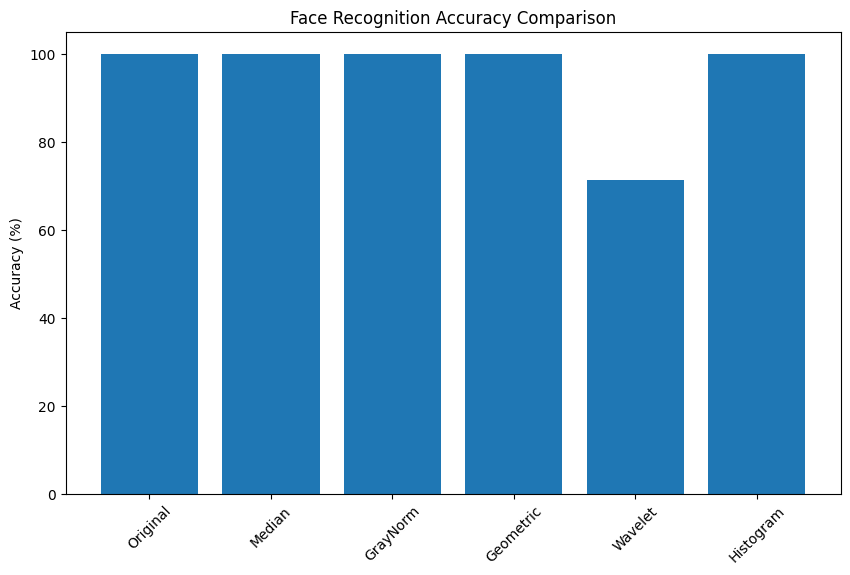

In [37]:
methods_list = [r[0] for r in results]
accuracies = [r[1] for r in results]

plt.figure(figsize=(10,6))
plt.bar(methods_list, accuracies)
plt.xticks(rotation=45)
plt.ylabel("Accuracy (%)")
plt.title("Face Recognition Accuracy Comparison")
plt.show()

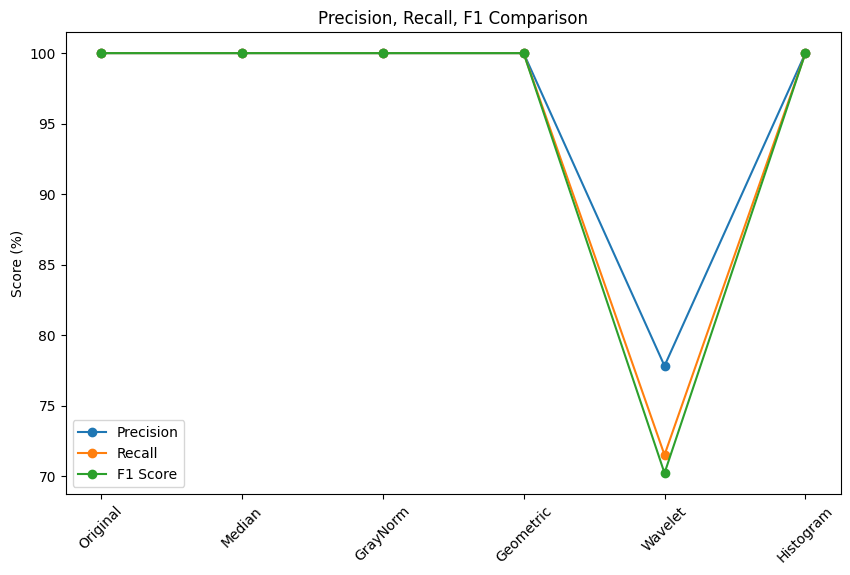

In [38]:
plt.figure(figsize=(10,6))

plt.plot(df["Method"], df["Precision"], marker='o', label="Precision")
plt.plot(df["Method"], df["Recall"], marker='o', label="Recall")
plt.plot(df["Method"], df["F1 Score"], marker='o', label="F1 Score")

plt.xticks(rotation=45)

plt.ylabel("Score (%)")
plt.title("Precision, Recall, F1 Comparison")

plt.legend()

plt.show()

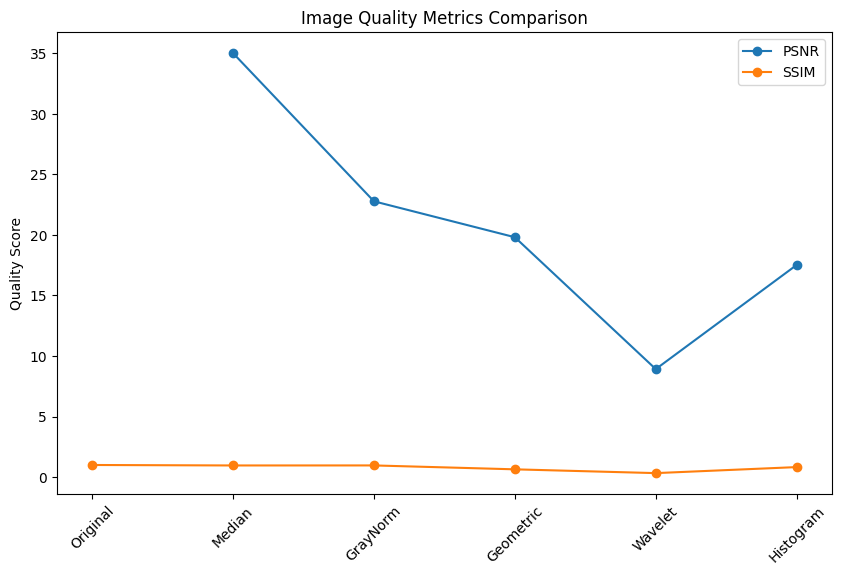

In [39]:
plt.figure(figsize=(10,6))

plt.plot(df["Method"], df["PSNR"], marker='o', label="PSNR")
plt.plot(df["Method"], df["SSIM"], marker='o', label="SSIM")

plt.xticks(rotation=45)

plt.ylabel("Quality Score")
plt.title("Image Quality Metrics Comparison")

plt.legend()

plt.show()

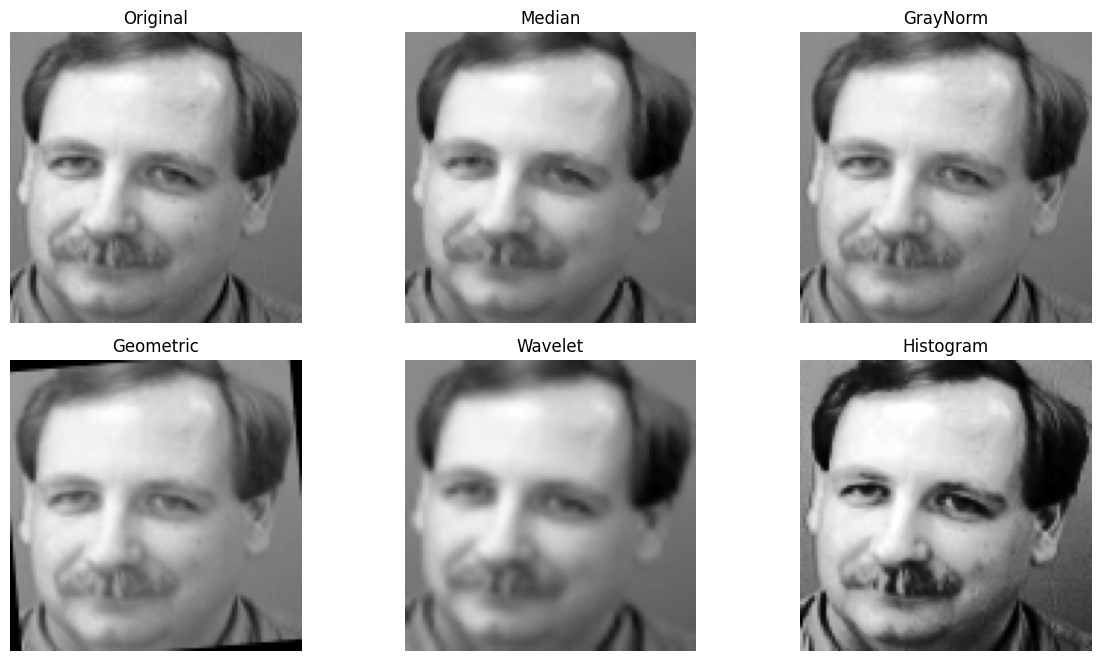

In [40]:
import matplotlib.pyplot as plt

sample = X_test[0]

plt.figure(figsize=(12,10))

# show original
plt.subplot(3,3,1)
plt.imshow(sample, cmap='gray')
plt.title("Original")
plt.axis("off")

i = 2

for name, func in methods.items():

    if name == "Original":
        continue

    processed = func(sample)

    plt.subplot(3,3,i)
    plt.imshow(processed, cmap='gray')
    plt.title(name)
    plt.axis("off")

    i += 1

plt.tight_layout()
plt.show()